In [21]:
import pandas as pd
import numpy as np 
import seaborn as sb
import matplotlib.pyplot as plt


In [22]:
df=pd.read_csv("../Datasets/Indian_Weddings_.csv")

In [23]:
df

,Unnamed: 0,Wedding/Type,Place,Cost/of/Type,Clothes/Bride,Clothes/Groom,Photography,Decor,Decor/Category,Entertainment,Entertainment/Category,Gifts(per/piece),Gifts/Category,Invitations/Cards,Cards/Category
0,0,Heritage Weddings,Jaipur,7437978,660719,457238,33533,533374,Luxury Package,417797,Celebrity Singers/Dancer,3589,High-Quality,180,Customized Invitations
1,1,Palace Weddings,Shimla,5777920,379302,316691,134543,496453,Luxury Package,322713,Celebrity Singers/Dancer,4421,Premium Perfumes,500,Boxed
2,2,Resort Weddings,Shimla,3243944,197374,108820,106831,527908,Luxury Package,414991,Celebrity Singers/Dancer,3185,High-Quality,452,Customized Invitations
3,3,Cruise Weddings,Alibaug,7064790,164124,115563,21246,411917,Luxury Package,282843,Celebrity Singers/Dancer,3581,High-Quality,744,Boxed
4,4,////Farmhouse Weddings////,Shimla,2675924,86758,77153,260566,279417,Floral Decor,102517,Professional Singer/Dance,4903,Premium Perfumes,694,Boxed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,4495,Hotel Weddings,Hyderabad,351231,90746,403998,212669,519830,Luxury Package,204726,Professional Singer/Dance,4038,Premium Perfumes,780,Boxed
4496,4496,Hotel Weddings,Tirupati,876370,66937,407991,197744,162554,Venue Decor/519830,26430,DJ/Sangeet,1123,Traditional Handicrafts,343,Customized Invitations
4497,4497,////Temple Weddings////,////Agatti Island////xc2,22518,28103,10286,23146,272210,Floral Decor,477426,Celebrity Singers/Dancer,3778,High-Quality,563,Boxed
4498,4498,Resort Weddings,Shimla,2379743,106716,120539,213517,220740,Floral Decor,145581,Professional Singer/Dance,3682,High-Quality,776,Boxed


In [65]:
colors = sb.color_palette("viridis", 4)

In [24]:
df.isnull().sum()

Unnamed: 0                0
Wedding/Type              0
Place                     0
Cost/of/Type              0
Clothes/Bride             0
Clothes/Groom             0
Photography               0
Decor                     0
Decor/Category            0
Entertainment             0
Entertainment/Category    0
Gifts(per/piece)          0
Gifts/Category            0
Invitations/Cards         0
Cards/Category            0
dtype: int64

In [25]:
df=df.drop('Unnamed: 0',axis=1)

In [26]:
df=df.rename(columns={'Wedding/Type':'Weddinng_Type','Cost/of/Type':'Cost_of_Type','Clothes/Bride':'Clothes_Bride','Clothes/Groom':'Clothes_Groom','Decor/Category':'Decor_Category','Entertainment/Category':'Entertainment_Category','Gifts(per/piece)':'Gifts_per_piece','Gifts/Category':'Gifts_Category','Cards/Category':'Cards_Category','Invitations/Cards':'Invitations_Cards'})

In [27]:
df=df.rename(columns={'Decor':'Decor_price'})

In [28]:
df=df.rename(columns={'Photography':'Photography_price'})

In [29]:
df=df.rename(columns={'Entertainment':'Entertainment_price'})

In [30]:
df.Weddinng_Type=df.Weddinng_Type.replace('[////]','',regex=True).astype('object')

In [31]:
df.Place=df.Place.replace('[////////xc2]','',regex=True).astype('object')

In [32]:
df.Decor_Category=df.Decor_Category.replace('[/519830]','',regex=True).astype('object')

In [33]:
df.Entertainment_Category=df.Entertainment_Category.replace('[/]','',regex=True).astype('object')

In [34]:
df.Gifts_Category=df.Gifts_Category.replace('[-]','',regex=True).astype('object')

In [35]:
df.Weddinng_Type.value_counts()

Weddinng_Type
Heritage Weddings       500
Palace Weddings         500
Resort Weddings         500
Cruise Weddings         500
Farmhouse Weddings      500
Beach Weddings          500
Temple Weddings         500
Hotel Weddings          500
Destination Weddings    500
Name: count, dtype: int64

#### The dataset is perfectly balanced, with each wedding type having exactly 500 entries.

In [72]:
df.Place.value_counts()

Place
Jaipur             225
Shimla             225
Alibaug            225
Neil Island        225
Mussoorie          225
Hyderabad          225
Bangaram Island    225
Goa                225
Mumbai             225
Agatti Island      225
Nainital           225
Bangalore          225
Varanasi           225
New Delhi          225
Udaipur            225
Jaisalmer          225
Lonavala           225
Rishikesh          225
Tirupati           225
Jodhpur            225
Name: count, dtype: int64

#### The dataset is evenly distributed across all locations, with each place having exactly 225 records.

In [73]:
df.Decor_Category.value_counts()

Decor_Category
Luxury Package    1671
Floral Decor      1629
Venue Decor       1133
Mandap              67
Name: count, dtype: int64

#### Luxury Package and Floral Decor dominate the dataset, indicating they are the most commonly chosen decor options.

In [74]:
df.Entertainment_Category.value_counts()

Entertainment_Category
Celebrity SingersDancer     2321
Professional SingerDance    1428
Live Band                    654
DJSangeet                     97
Name: count, dtype: int64

#### The dataset shows a high concentration in premium entertainment options, with Celebrity Singers/Dancers being the most common.

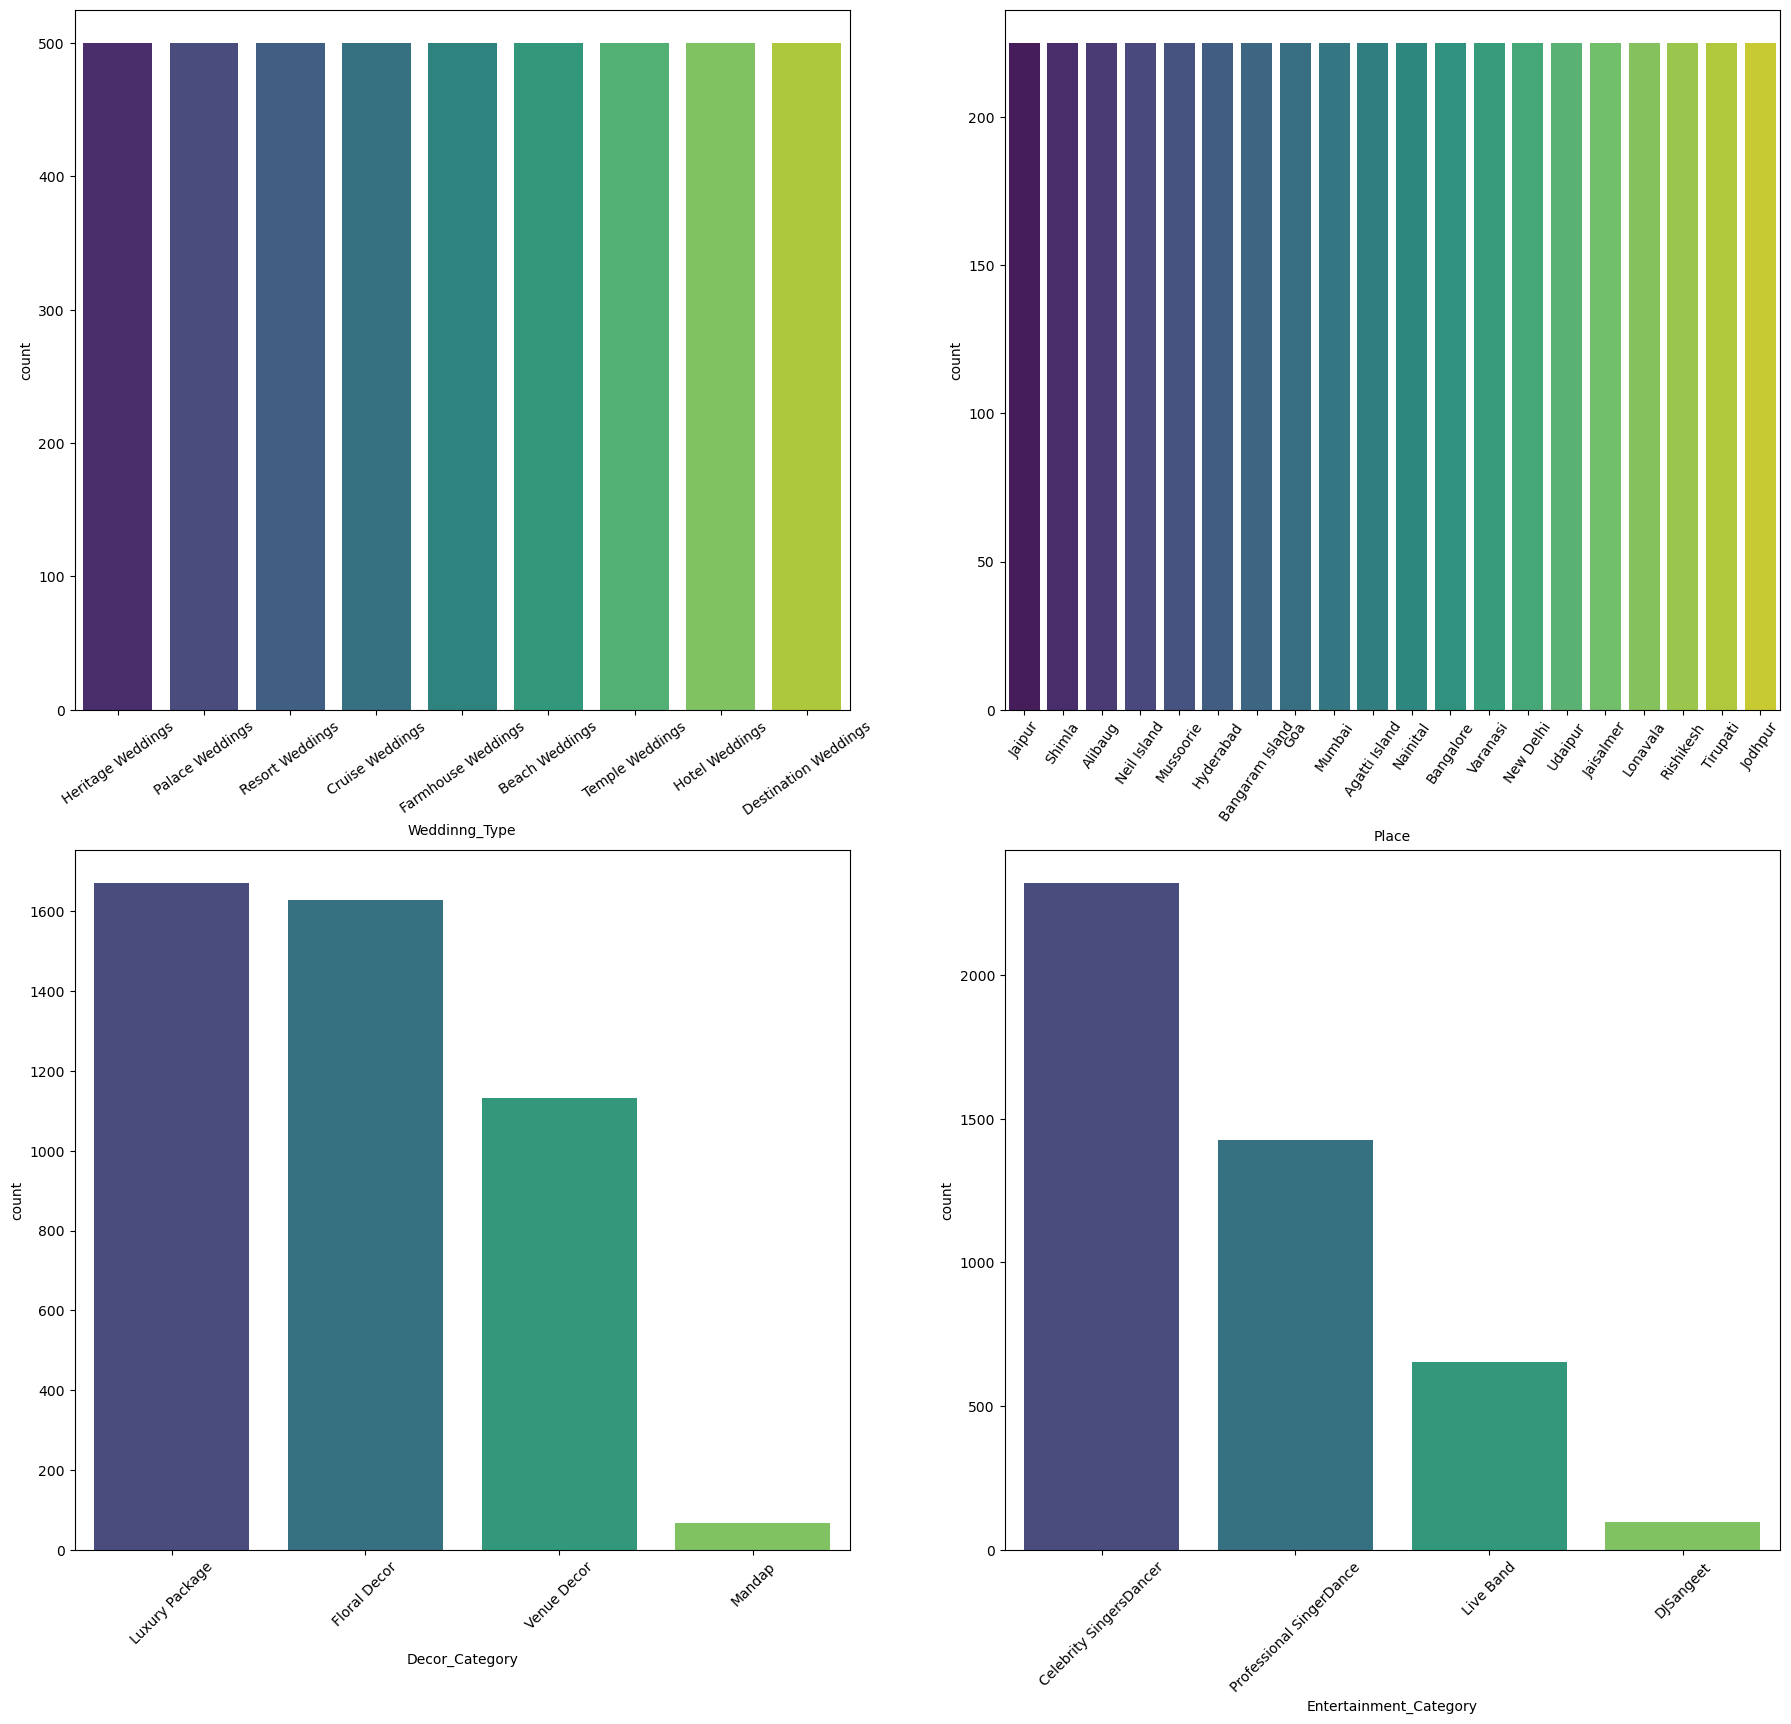

In [99]:
fig=plt.figure(figsize=[22,20])
fig.add_subplot(221)
sb.countplot(x=df.Weddinng_Type,palette="viridis",hue=df.Weddinng_Type,legend=False)
plt.xticks(rotation = 35)
fig.add_subplot(222)
sb.countplot(x=df.Place,palette="viridis",hue=df.Place,legend=False)
plt.xticks(rotation = 55)
fig.add_subplot(223)
sb.countplot(x=df.Decor_Category,palette="viridis",hue=df.Decor_Category,legend=False)
plt.xticks(rotation = 45)
fig.add_subplot(224)
sb.countplot(x=df.Entertainment_Category,palette="viridis",hue=df.Entertainment_Category,legend=False)
plt.xticks(rotation = 45)
plt.show()

#### The Wedding Type and Place show even distribution of count, in Decor Category Luxury package appearance is most and in Entertainment Category Celebrity Singers/Dancer appear much more than others.

In [75]:
df.Gifts_Category.value_counts()

Gifts_Category
HighQuality                1997
Traditional Handicrafts    1015
Premium Perfumes           1004
Edible                      484
Name: count, dtype: int64

#### High-quality gifts dominate the dataset, indicating a strong preference for premium gifting, while edible gifts are least favored.

In [76]:
df.Cards_Category.value_counts()

Cards_Category
Customized Invitations    1915
Boxed                     1428
Scroll Invitations         921
Traditional Paper          236
Name: count, dtype: int64

#### Customized invitations are the most preferred, while traditional paper cards are the least used.

In [77]:
df.describe()

,Cost_of_Type,Clothes_Bride,Clothes_Groom,Photography_price,Decor_price,Entertainment_price,Gifts_per_piece,Invitations_Cards
count,4.500000e+03,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,3.912262e+06,258082.149111,192349.117111,161921.164444,326960.379556,259857.117556,2753.392222,521.595111
std,2.895702e+06,255273.762542,191384.209107,81144.000934,158142.530687,138312.954055,1304.755182,271.963845
min,1.515200e+04,15005.000000,5010.000000,20042.000000,50021.000000,20108.000000,500.000000,50.000000
25%,1.713427e+06,75530.750000,58418.000000,94058.250000,191784.250000,141277.500000,1616.250000,283.000000
50%,3.447512e+06,140873.000000,113357.000000,161848.000000,326343.000000,255375.000000,2749.000000,521.000000
75%,5.850611e+06,448758.250000,293082.750000,231259.000000,459184.750000,380986.500000,3864.000000,756.000000
max,1.199208e+07,999492.000000,898366.000000,299991.000000,599856.000000,499997.000000,4998.000000,999.000000


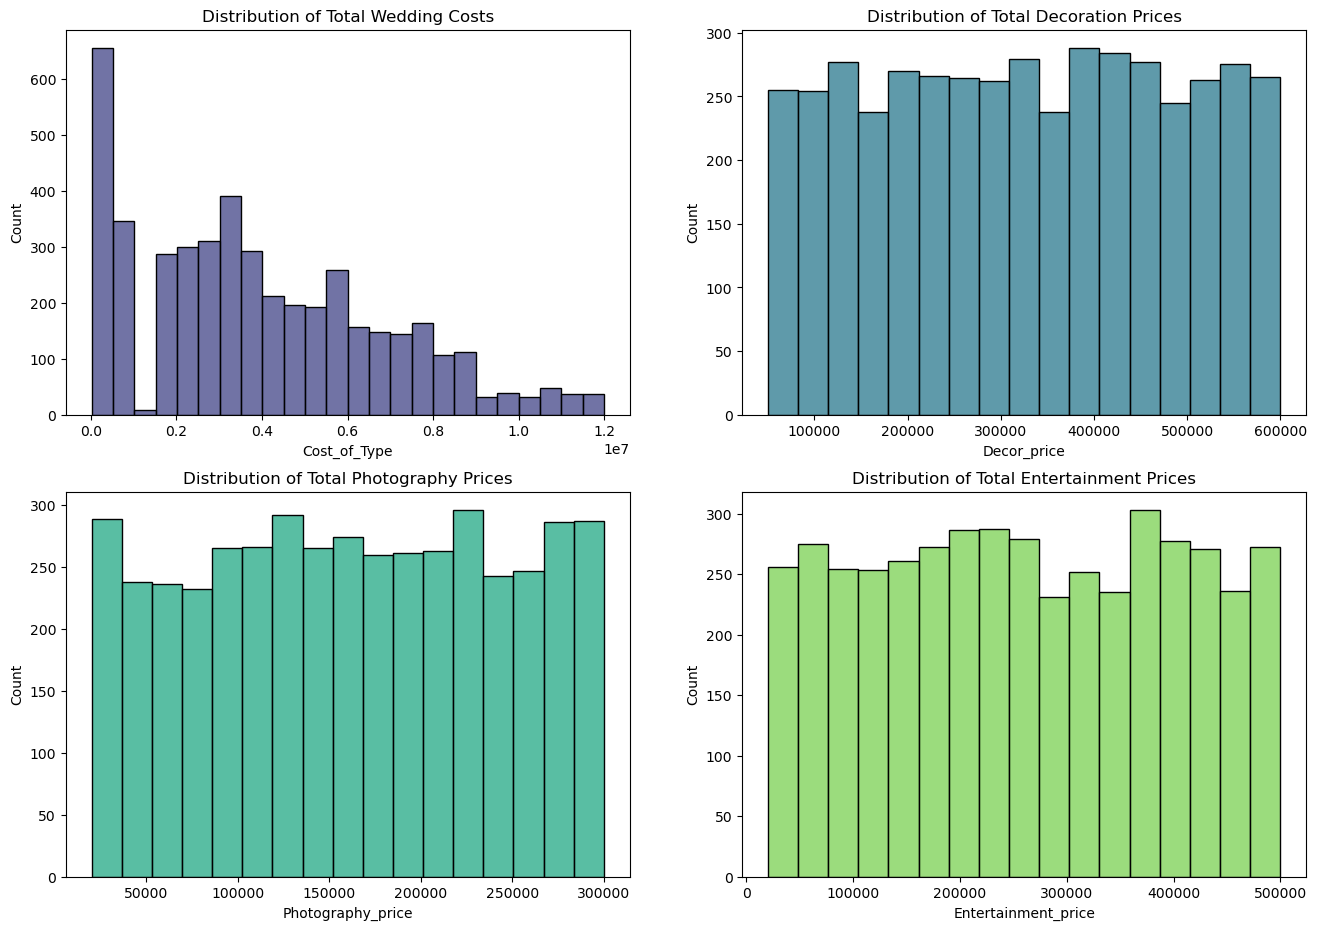

In [66]:
fig=plt.figure(figsize=[16,11])
fig.add_subplot(221)
sb.histplot(df.Cost_of_Type,color=colors[0])
plt.title('Distribution of Total Wedding Costs')
fig.add_subplot(222)
sb.histplot(df.Decor_price,color=colors[1])
plt.title('Distribution of Total Decoration Prices')
fig.add_subplot(223)
sb.histplot(df.Photography_price,color=colors[2])
plt.title('Distribution of Total Photography Prices')
fig.add_subplot(224)
sb.histplot(df.Entertainment_price,color=colors[3])
plt.title('Distribution of Total Entertainment Prices')
plt.show()


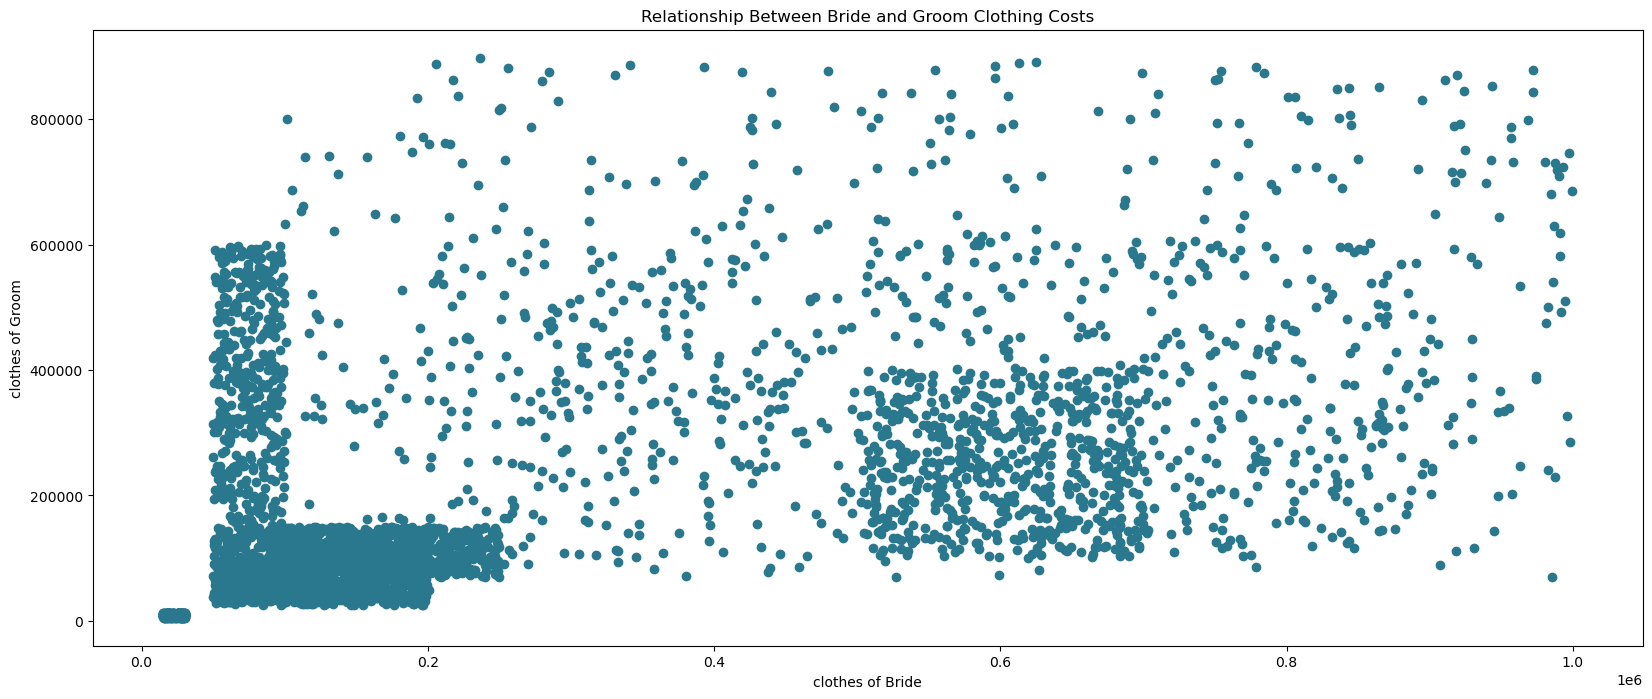

In [69]:
plt.figure(figsize=(20,8))
plt.scatter(df.Clothes_Bride,df.Clothes_Groom,color=colors[1])
plt.xlabel('clothes of Bride')
plt.ylabel('clothes of Groom')
plt.title('Relationship Between Bride and Groom Clothing Costs')
plt.show()

#### The scatter plot shows that the bride’s clothing cost is generally higher and more varied than the groom’s, indicating greater spending and variability on bridal attire in weddings.

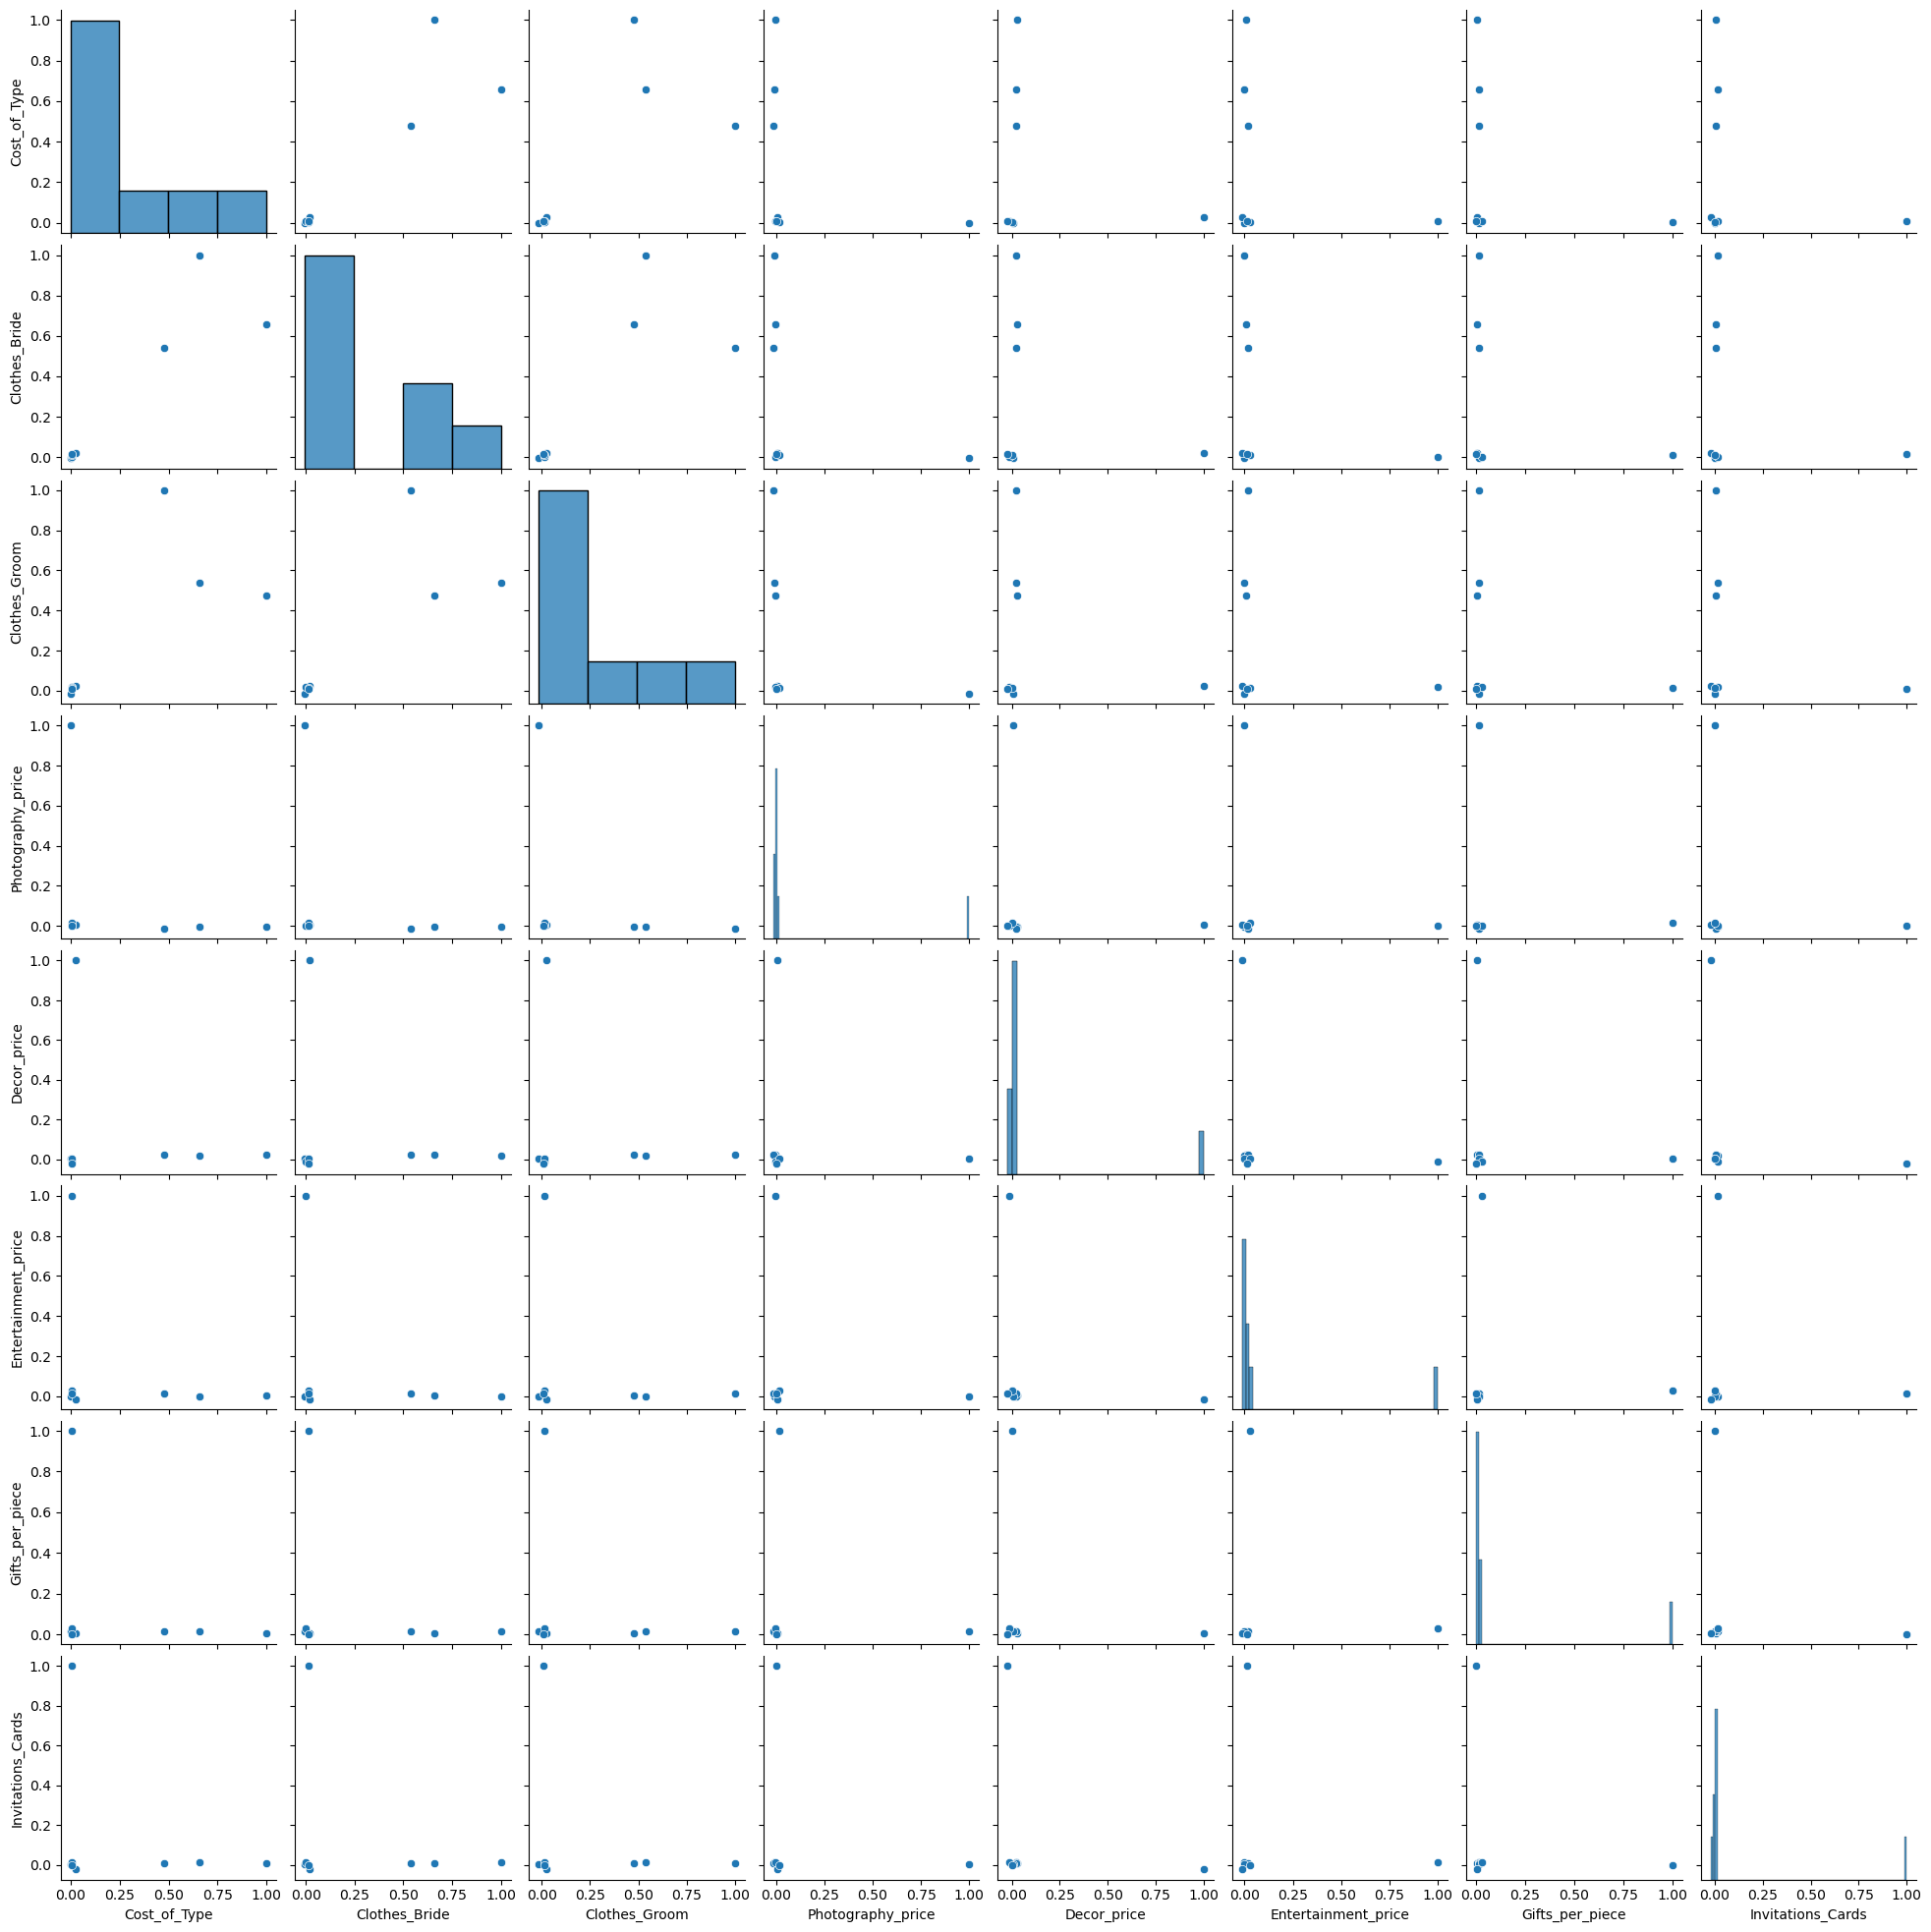

In [74]:
corr_matrix=df.corr(numeric_only=True)
sb.pairplot(corr_matrix)
plt.show()

In [41]:
Wedding_cost=df.groupby('Weddinng_Type')['Cost_of_Type'].mean()

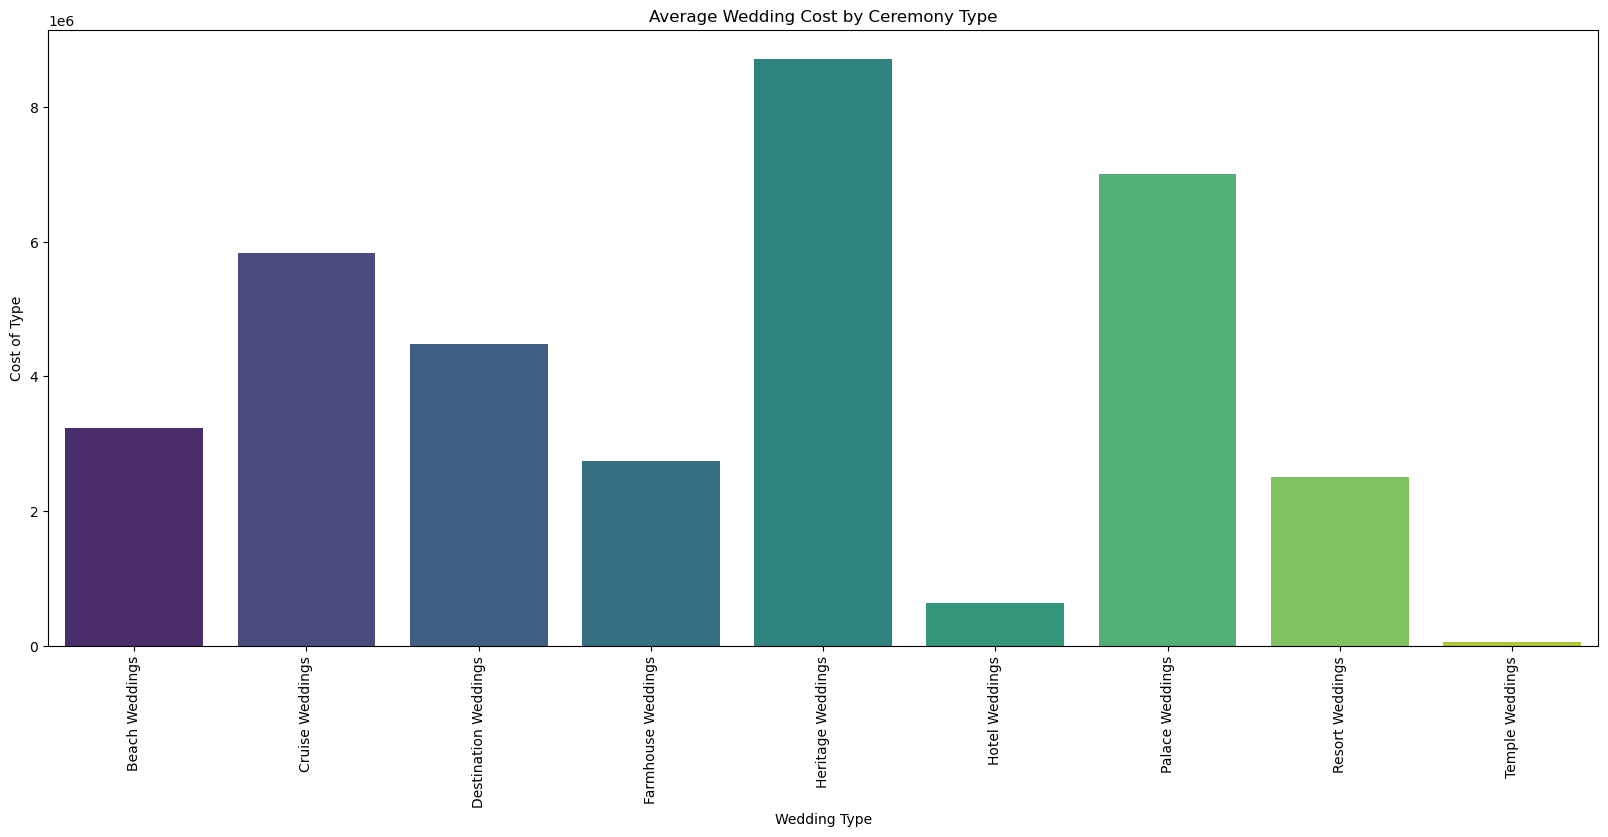

In [42]:
plt.figure(figsize=(20,8))
sb.barplot(x=Wedding_cost.index,y=Wedding_cost.values,palette="viridis",hue=Wedding_cost.index,legend=False)
plt.xlabel('Wedding Type')
plt.ylabel('Cost of Type')
plt.title('Average Wedding Cost by Ceremony Type')
plt.xticks(rotation = 90)
plt.show()

#### The analysis shows that heritage weddings,Palace Weddings and Cruise Weddings are the most expensive among all wedding types.

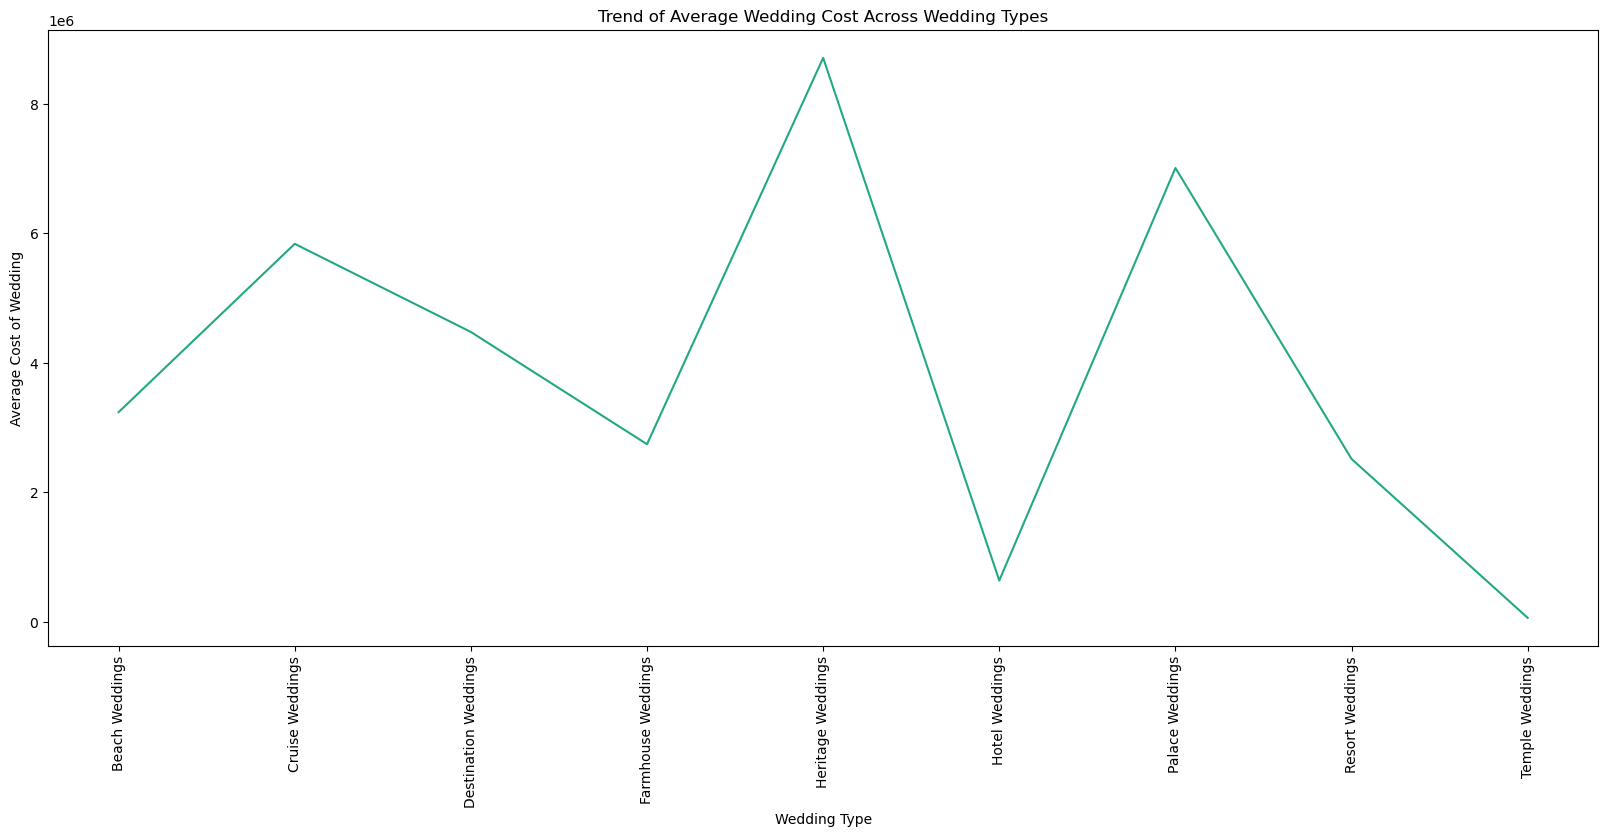

In [75]:
plt.figure(figsize=(20,8))
sb.lineplot(x=Wedding_cost.index,y=Wedding_cost.values,color=colors[2])
plt.xticks(rotation = 90)
plt.xlabel('Wedding Type')
plt.ylabel('Average Cost of Wedding')
plt.title('Trend of Average Wedding Cost Across Wedding Types')
plt.show()

### This Analysis shows that Luxury Category Weddings is more costlier than normal weddings types.

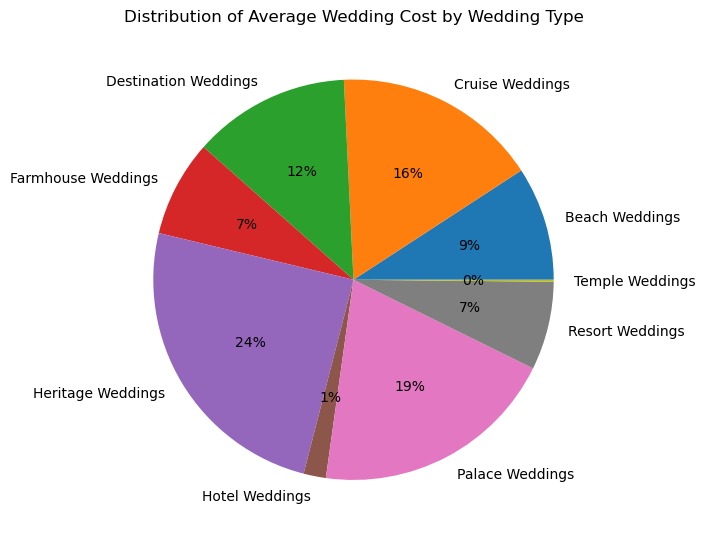

In [45]:
fig=plt.figure(figsize=(7,6.5))
plt.pie(Wedding_cost.values,labels=Wedding_cost.index,autopct='%d%%')
plt.title('Distribution of Average Wedding Cost by Wedding Type')
plt.show()


### Heritage Weddings,Palace weddings and Cruise Weddings fall in High-Cost segment,
### Beach Weddings,Farmhouse weddings and Resort Weddings fall in Mid-Range segments,
### Temple Weddings and Hotel Weddings fall in Low-Cost segments.

In [46]:
location_cost=df.groupby('Place')['Cost_of_Type'].mean()

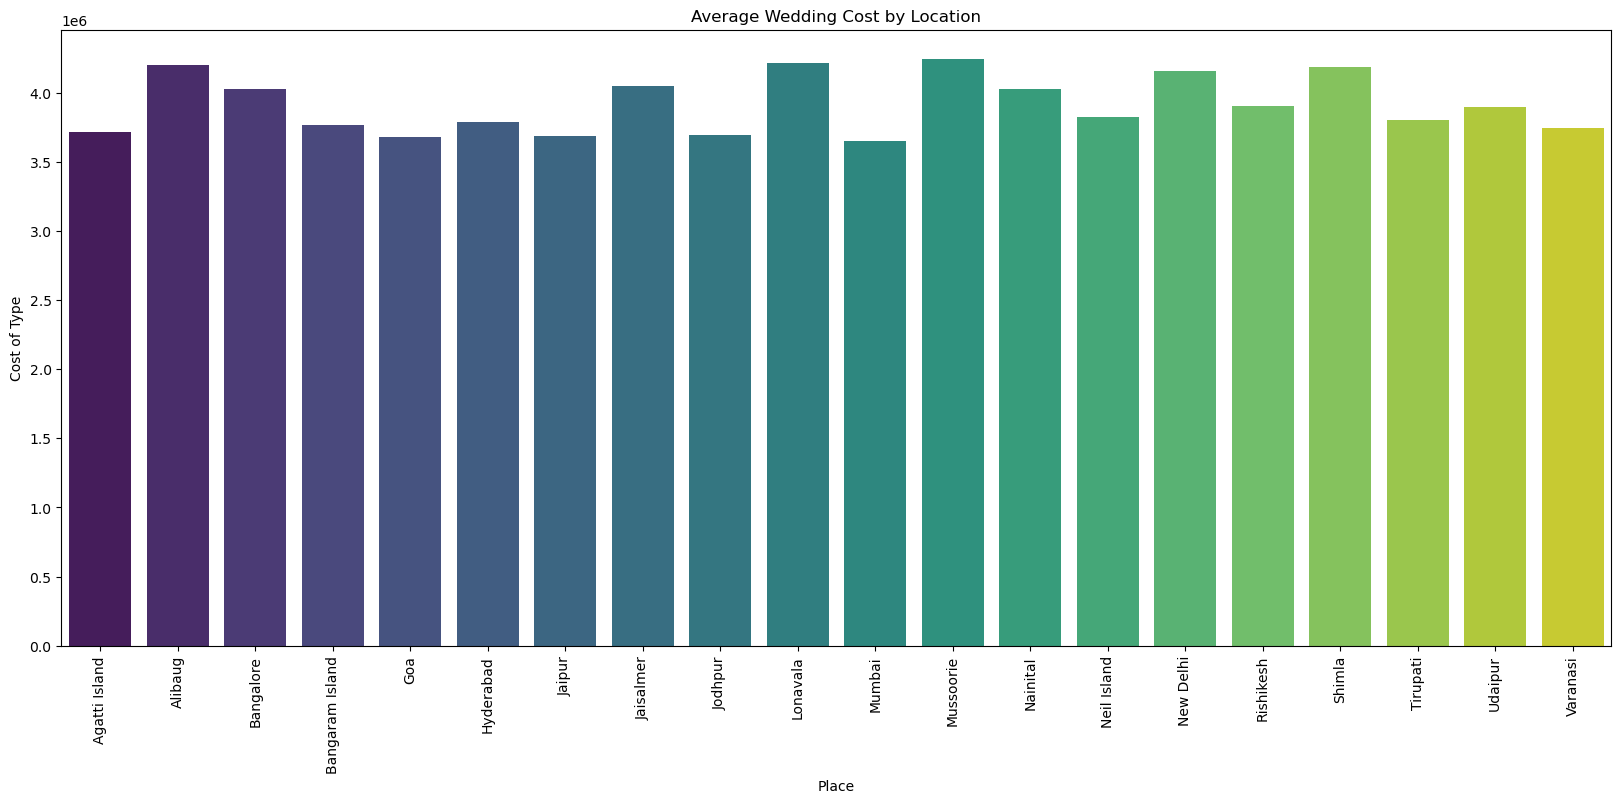

In [47]:
plt.figure(figsize=(20,8))
sb.barplot(x=location_cost.index,y=location_cost.values,palette="viridis",hue=location_cost.index,legend=False)
plt.xlabel('Place')
plt.ylabel('Cost of Type')
plt.title('Average Wedding Cost by Location')
plt.xticks(rotation = 90)
plt.show()

#### The analysis shows that Lonavala,Alibaug and Mussoorie are most expensive costing more than 40L

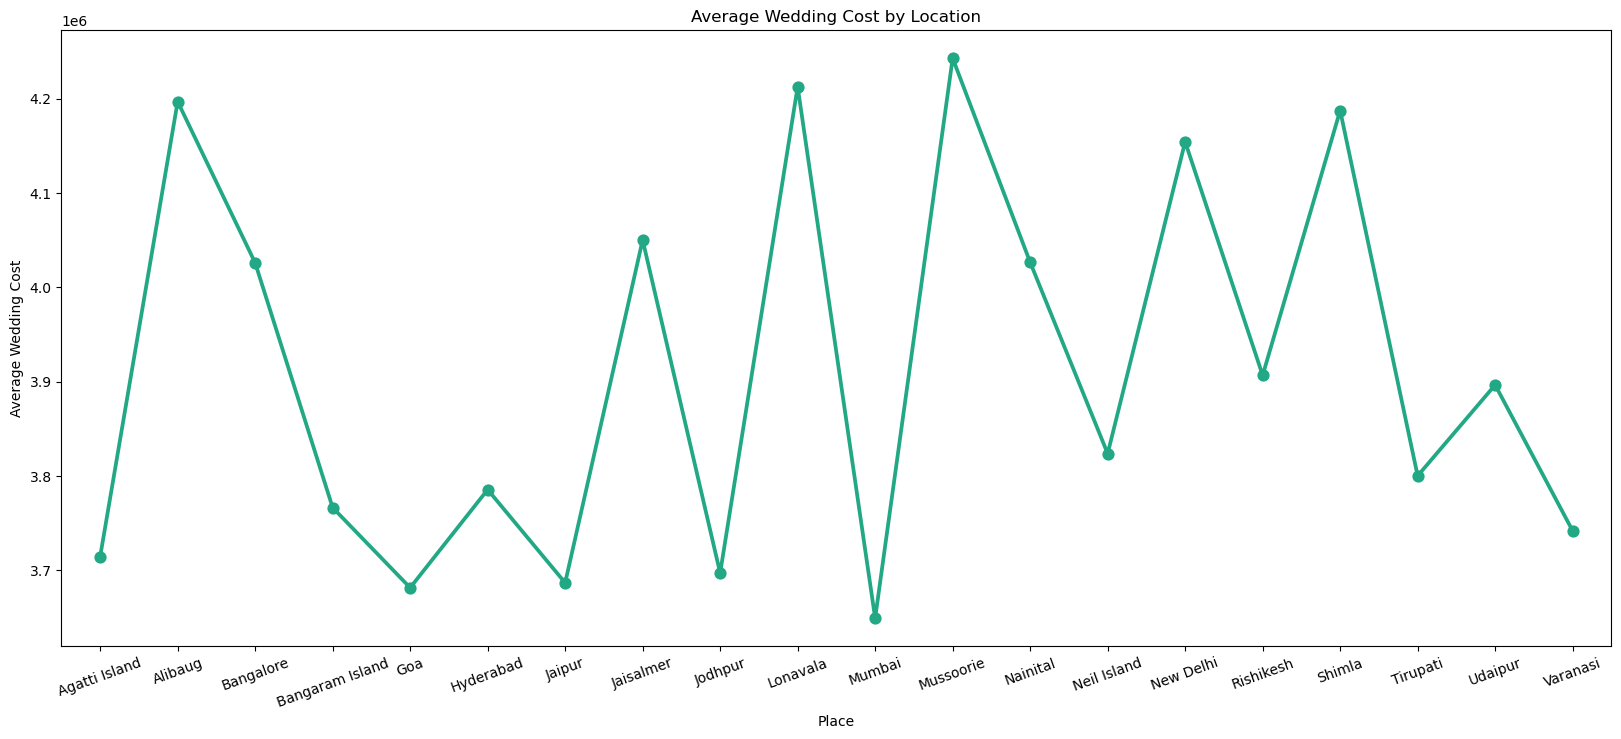

In [76]:
plt.figure(figsize=(20,8))
sb.pointplot(x=location_cost.index,y=location_cost.values,color=colors[2])
plt.xlabel('Place')
plt.ylabel('Average Wedding Cost')
plt.title('Average Wedding Cost by Location')
plt.xticks(rotation=20)
plt.show()

#### The Analysis shows that Mussoorie is most costliest place for wedding than others.

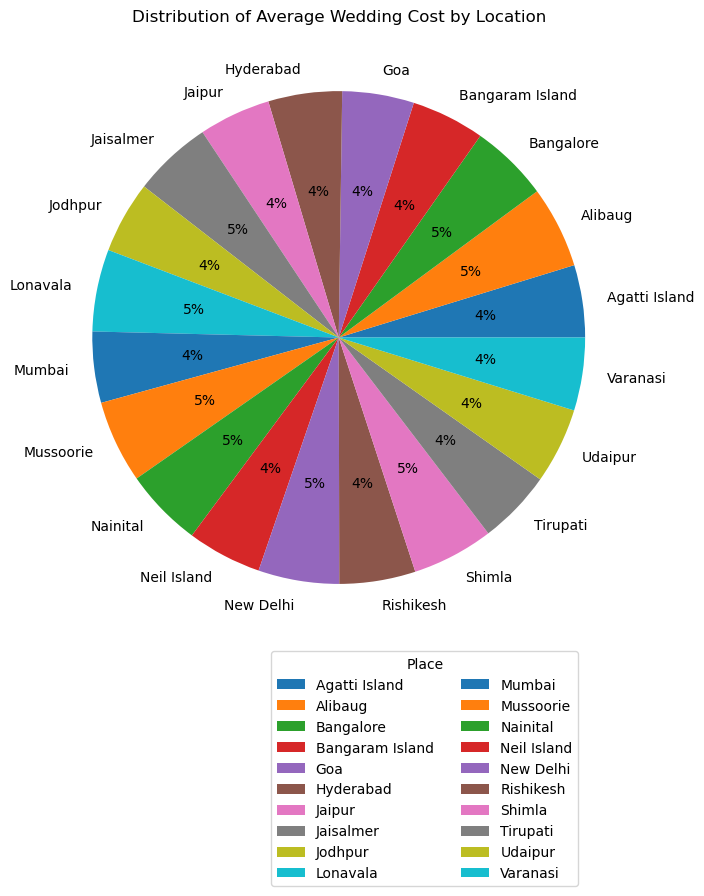

In [48]:
fig=plt.figure(figsize=(8,8))
plt.pie(location_cost.values,labels=location_cost.index,autopct='%d%%')
plt.title('Distribution of Average Wedding Cost by Location')
plt.legend(title='Place',loc='center right',bbox_to_anchor=(0,0,0.9,-0.4),ncol=2)
plt.show()

#### The Analysis Shows that perfectly even distribution of average wedding costs across all locations. 

In [51]:
Wedding_decor=df.groupby('Weddinng_Type')['Decor_price'].mean()

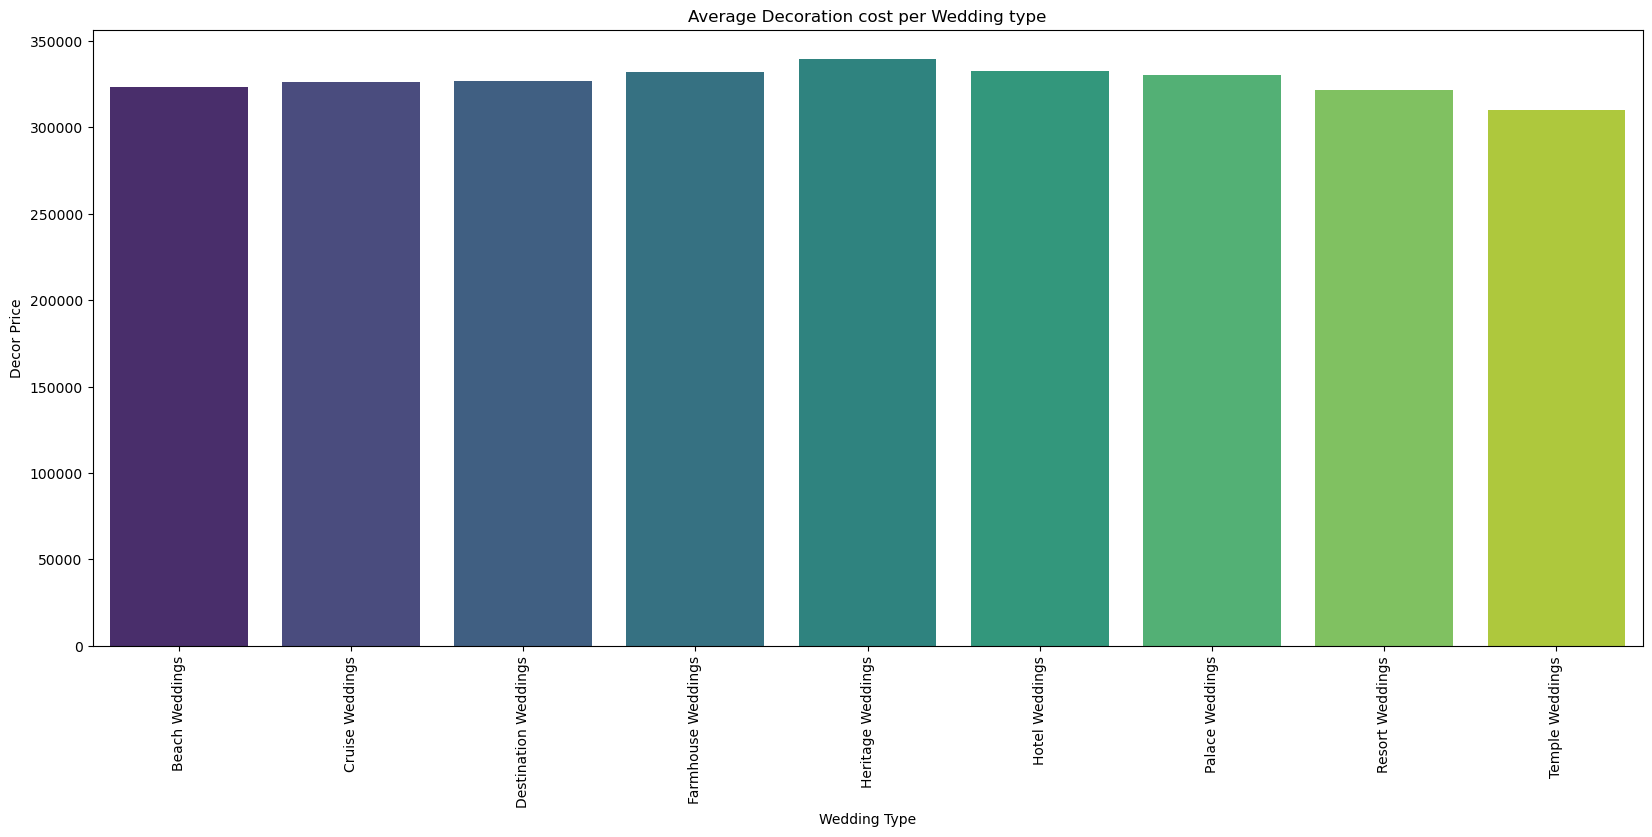

In [52]:
plt.figure(figsize=(20,8))
sb.barplot(x=Wedding_decor.index,y=Wedding_decor.values,palette="viridis",hue=Wedding_decor.index,legend=False)
plt.xlabel('Wedding Type')
plt.ylabel('Decor Price')
plt.title('Average Decoration cost per Wedding type')
plt.xticks(rotation = 90)
plt.show()

#### The Analysis shows that Heritage Weddings Decor Price is more costlier than other Wedding Types.

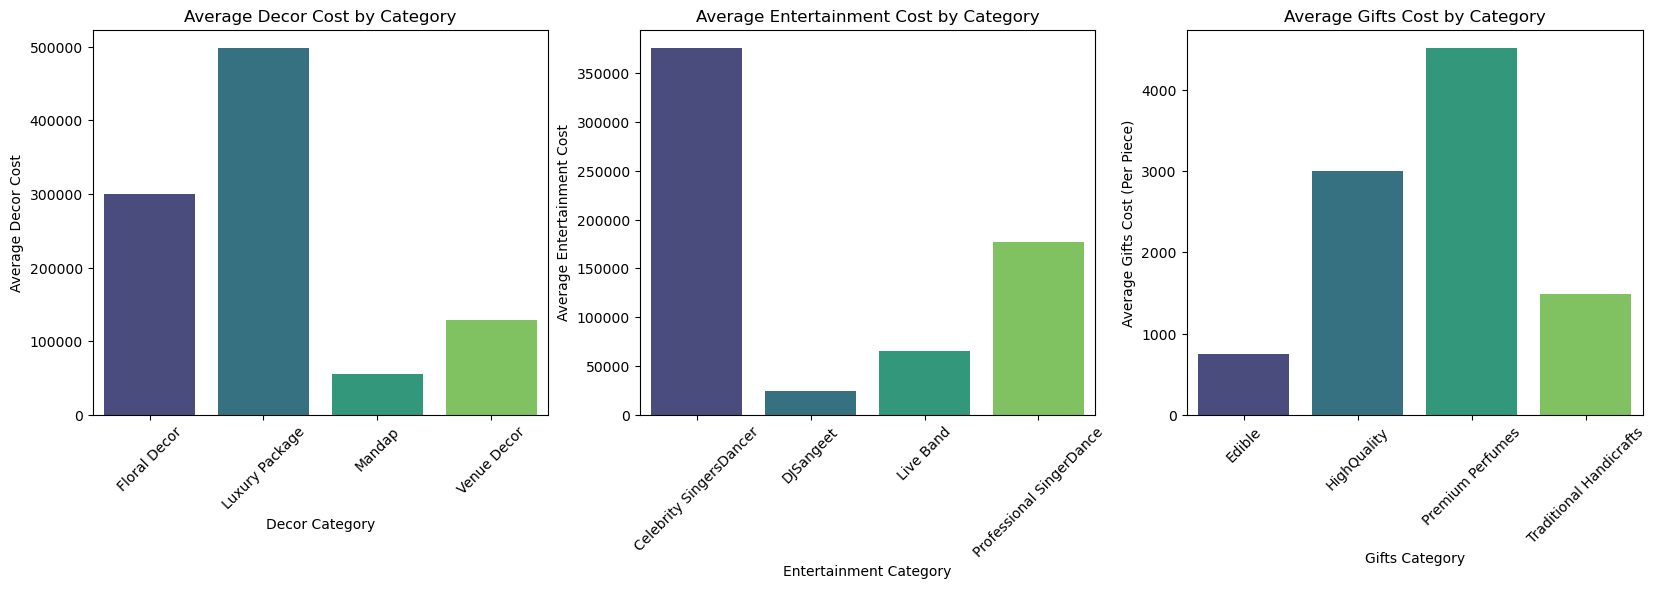

In [53]:
Decor_cost=df.groupby('Decor_Category')['Decor_price'].mean()
Entertainment_cost=df.groupby('Entertainment_Category')['Entertainment_price'].mean()
Gift_cost=df.groupby('Gifts_Category')['Gifts_per_piece'].mean()

fig=plt.figure(figsize=[20,5])

fig.add_subplot(131)
sb.barplot(x=Decor_cost.index,y=Decor_cost.values,palette="viridis",hue=Decor_cost.index,legend=False)
plt.xlabel('Decor Category')
plt.ylabel('Average Decor Cost')
plt.title('Average Decor Cost by Category')
plt.xticks(rotation = 45)

fig.add_subplot(132)
sb.barplot(x=Entertainment_cost.index,y=Entertainment_cost.values,palette="viridis",hue=Entertainment_cost.index,legend=False)
plt.xlabel('Entertainment Category')
plt.ylabel('Average Entertainment Cost')
plt.title('Average Entertainment Cost by Category')
plt.xticks(rotation = 45)

fig.add_subplot(133)
sb.barplot(x=Gift_cost.index,y=Gift_cost.values,palette="viridis",hue=Gift_cost.index,legend=False)
plt.xlabel('Gifts Category')
plt.ylabel('Average Gifts Cost (Per Piece)')
plt.title('Average Gifts Cost by Category')
plt.xticks(rotation = 45)

plt.show()

#### In the first graph the Luxury Package is most expensive in Decor Category,
#### the second graph indicates CelebritySingers/Dancers has more charges in Entertainment Category, 
#### the third graph shows Premium Perfumes is most expensive than other gift categories.

In [54]:
a=pd.pivot_table(df,index='Place',
              columns='Weddinng_Type',
              values='Cost_of_Type',
              aggfunc='mean',
              margins=True)
a

Weddinng_Type,Beach Weddings,Cruise Weddings,Destination Weddings,Farmhouse Weddings,Heritage Weddings,Hotel Weddings,Palace Weddings,Resort Weddings,Temple Weddings,All
Place,,,,,,,,,,
Agatti Island,3.018720e+06,5.599684e+06,4.232670e+06,2.602561e+06,8.485356e+06,593907.047619,7.003253e+06,2.362398e+06,54227.290323,3.714367e+06
Alibaug,3.130439e+06,5.953619e+06,4.314194e+06,2.761478e+06,9.067060e+06,606857.894737,7.125760e+06,2.481228e+06,60603.413793,4.196844e+06
Bangalore,3.137503e+06,5.934097e+06,4.690533e+06,2.827003e+06,9.375914e+06,640712.312500,6.863055e+06,2.649649e+06,67020.500000,4.025909e+06
Bangaram Island,3.489743e+06,6.215923e+06,3.944307e+06,2.703541e+06,8.565992e+06,666449.500000,6.962396e+06,2.399040e+06,58765.280000,3.766360e+06
Goa,3.372831e+06,5.672584e+06,4.411652e+06,2.743029e+06,7.352064e+06,561192.840000,7.280374e+06,2.591701e+06,53515.034483,3.681406e+06
Hyderabad,3.139120e+06,6.148453e+06,4.486889e+06,2.733396e+06,9.276626e+06,685365.333333,7.025195e+06,2.856316e+06,55142.360000,3.785426e+06
Jaipur,3.435354e+06,6.022499e+06,4.465238e+06,2.940535e+06,8.250600e+06,681963.037037,6.825273e+06,2.523480e+06,51925.086957,3.686649e+06
Jaisalmer,3.203456e+06,5.883751e+06,4.516040e+06,2.633339e+06,9.173824e+06,706445.040000,7.164603e+06,2.610071e+06,61881.200000,4.050064e+06
Jodhpur,3.085721e+06,5.412297e+06,4.111385e+06,2.821599e+06,9.078724e+06,655542.967742,7.203812e+06,2.570956e+06,66149.615385,3.697000e+06


#### This Analysis Shows that Mussoorie is the costliest city for Wedding. Heritage weddings in metropolitan hubs like Bangalore and Hyderabad command the highest premiums, while Temple weddings remain the most cost-effective choice across all geographical locations.

In [55]:
b=pd.pivot_table(df,index='Weddinng_Type',
              columns='Decor_Category',
              values='Decor_price',
              aggfunc='mean',
              margins=True)
b

Decor_Category,Floral Decor,Luxury Package,Mandap,Venue Decor,All
Weddinng_Type,,,,,
Beach Weddings,298666.468421,500116.769663,56033.000000,123695.531746,323378.498000
Cruise Weddings,304377.240642,498850.365169,56994.000000,131126.196970,326387.098000
Destination Weddings,297909.338624,494772.576087,55553.700000,131988.555556,326682.434000
Farmhouse Weddings,306232.218391,497585.041451,54932.142857,129500.253968,332039.752000
Heritage Weddings,299675.789773,501587.887255,54077.666667,126049.596491,339521.976000
Hotel Weddings,303936.565217,498630.500000,55184.833333,127091.900000,332492.520000
Palace Weddings,296340.389535,496876.517766,53482.600000,127104.928571,330275.710000
Resort Weddings,295525.321429,499619.886486,56616.750000,131353.345324,321577.964000
Temple Weddings,295854.767196,495173.672840,55355.687500,136265.827068,310287.464000


#### The Analysis shows that Heritage Weddings take most amount for decoration. Also, In Floral Category Farmhouse Weddings take more amount for decoration, In Luxury Package Heritage Weddings take more amount for decoration, In Mandap category  Cruise Weddings take more amount for decoration and at last In Venue Decor Temple Weddings take more amount for decoration.

In [56]:
c=pd.pivot_table(df,index='Weddinng_Type',
              columns='Entertainment_Category',
              values='Entertainment_price',
              aggfunc='mean',
              margins=True)
c

Entertainment_Category,Celebrity SingersDancer,DJSangeet,Live Band,Professional SingerDance,All
Weddinng_Type,,,,,
Beach Weddings,367672.867384,23924.363636,69101.690141,178420.345324,265101.092000
Cruise Weddings,374607.604743,25061.538462,67592.352113,175927.435583,257153.506000
Destination Weddings,377261.531120,24984.666667,63523.716049,171658.911243,250601.336000
Farmhouse Weddings,379312.988506,23685.142857,63875.291139,178957.098039,263186.140000
Heritage Weddings,374825.713208,23313.272727,63937.219178,174784.225166,261290.190000
Hotel Weddings,372448.767442,25193.666667,65124.031250,177218.385542,259960.592000
Palace Weddings,382213.812030,25360.666667,62461.267606,179917.000000,268078.176000
Resort Weddings,377206.510917,25717.285714,64729.585366,179923.508571,247069.546000
Temple Weddings,375168.609665,25010.181818,66711.451613,175982.037975,266273.480000


#### This Analysis describes that in Palace Weddings the charges for entertainment is more and mostly Celebrity Singers/Dancer are used.

In [57]:
d=pd.pivot_table(df,index='Weddinng_Type',
              columns='Cards_Category',
              values='Invitations_Cards',
              aggfunc='mean',
              margins=True)
d

Cards_Category,Boxed,Customized Invitations,Scroll Invitations,Traditional Paper,All
Weddinng_Type,,,,,
Beach Weddings,645.209040,300.078431,893.988889,75.034483,516.106000
Cruise Weddings,642.524691,298.031390,890.545455,71.562500,519.718000
Destination Weddings,651.145570,313.857820,890.679245,73.480000,530.708000
Farmhouse Weddings,657.748344,294.891892,903.388350,78.541667,519.440000
Heritage Weddings,656.917241,299.182648,898.357143,74.000000,526.332000
Hotel Weddings,658.436709,297.210762,895.989796,72.857143,519.296000
Palace Weddings,644.903846,293.690355,899.807018,75.666667,527.074000
Resort Weddings,645.621951,296.897059,894.900990,75.709677,518.362000
Temple Weddings,647.624204,311.915094,902.826531,72.121212,517.320000


#### The Analysis shows that Destination Weddings uses maximum numbber of Invitation Cards and mostly Scroll Invitations are used in Destination Weddings.

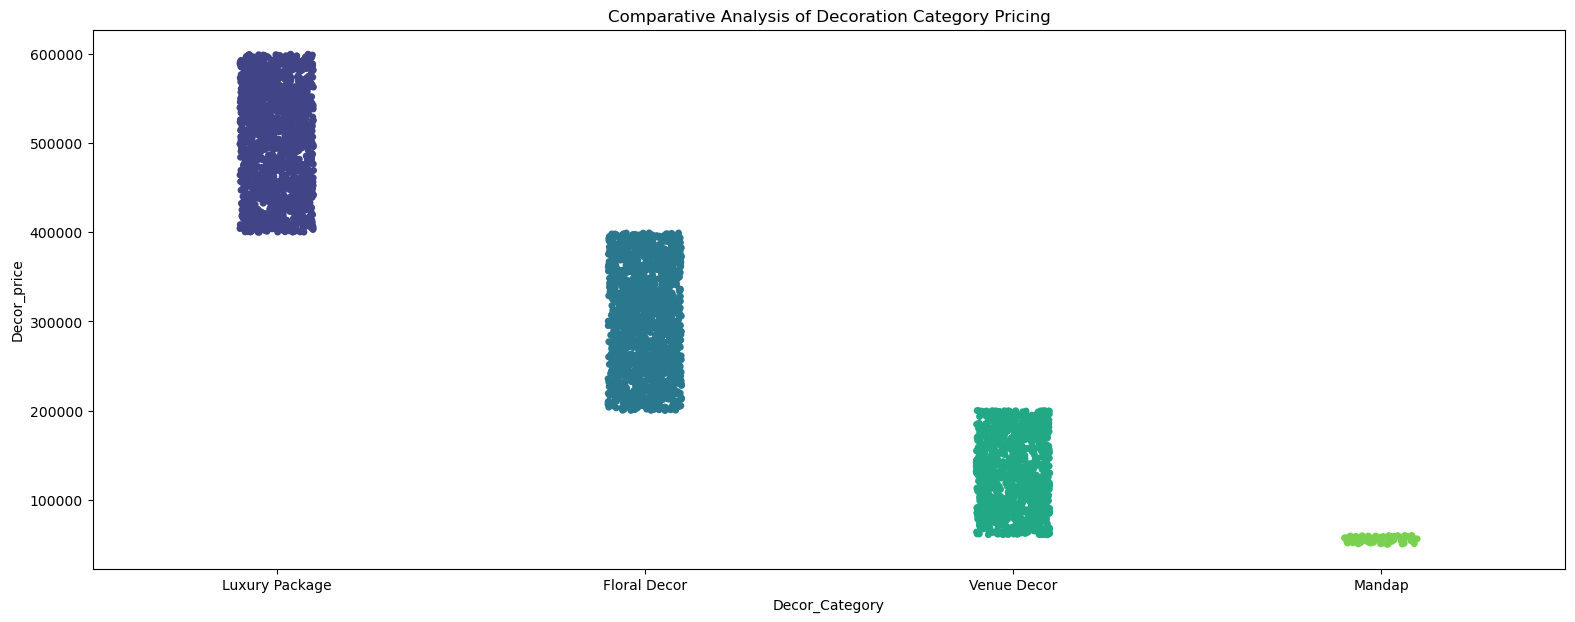

In [94]:
fig=plt.figure(figsize=[19,7])
sb.stripplot(x=df.Decor_Category,y=df.Decor_price,palette="viridis",hue=df.Decor_Category,legend=False)
plt.title('Comparative Analysis of Decoration Category Pricing')
plt.show()

#### The Analysis shows that Luxury Package is most costliest and Mandap is most cheaper in Decor Category

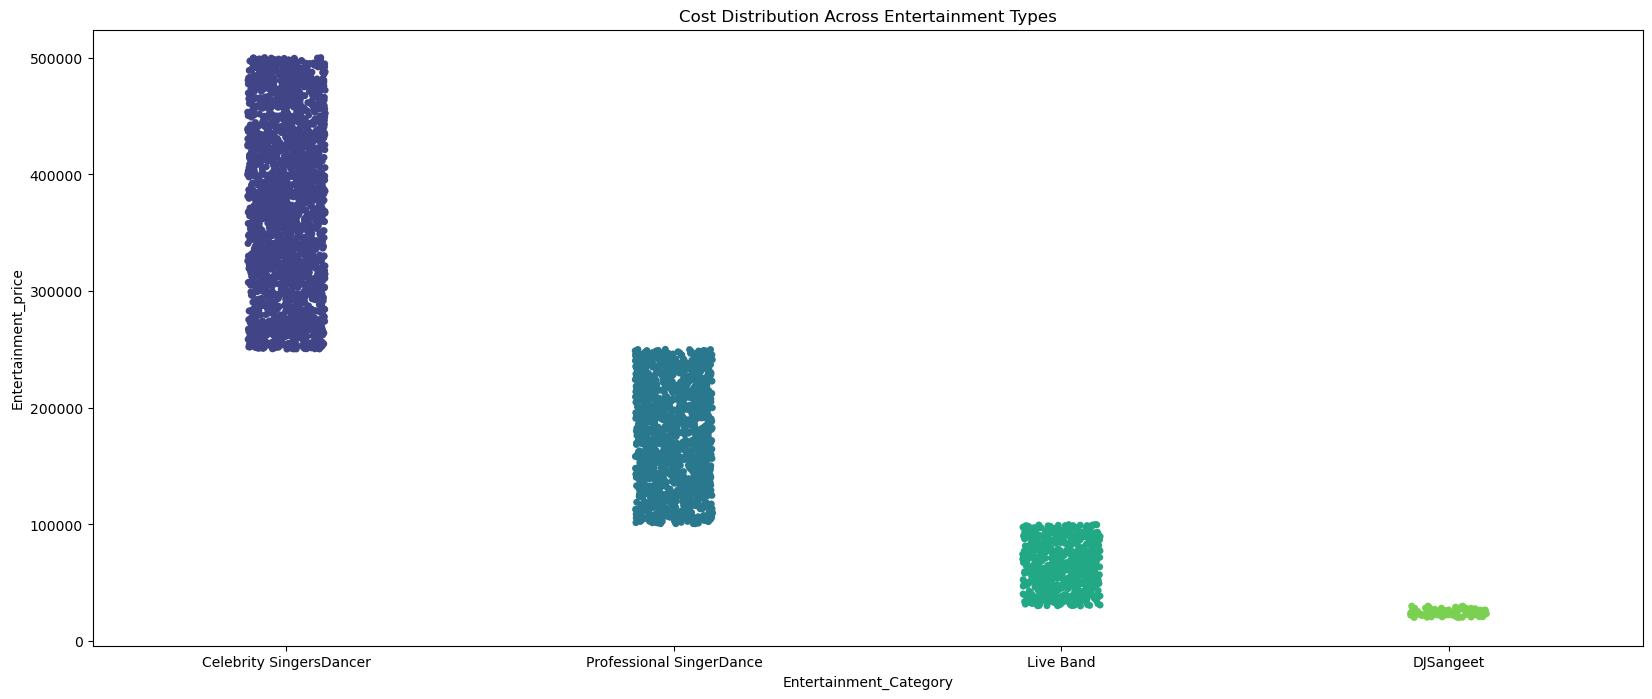

In [95]:
fig=plt.figure(figsize=[20,8])
sb.stripplot(x=df.Entertainment_Category,y=df.Entertainment_price,palette="viridis",hue=df.Entertainment_Category,legend=False)
plt.title('Cost Distribution Across Entertainment Types')
plt.show()

#### The Analysis shows that Celibrity Singers/Dancers take more amount and DJ Sangeet is more Affordable in Entertainment Category.


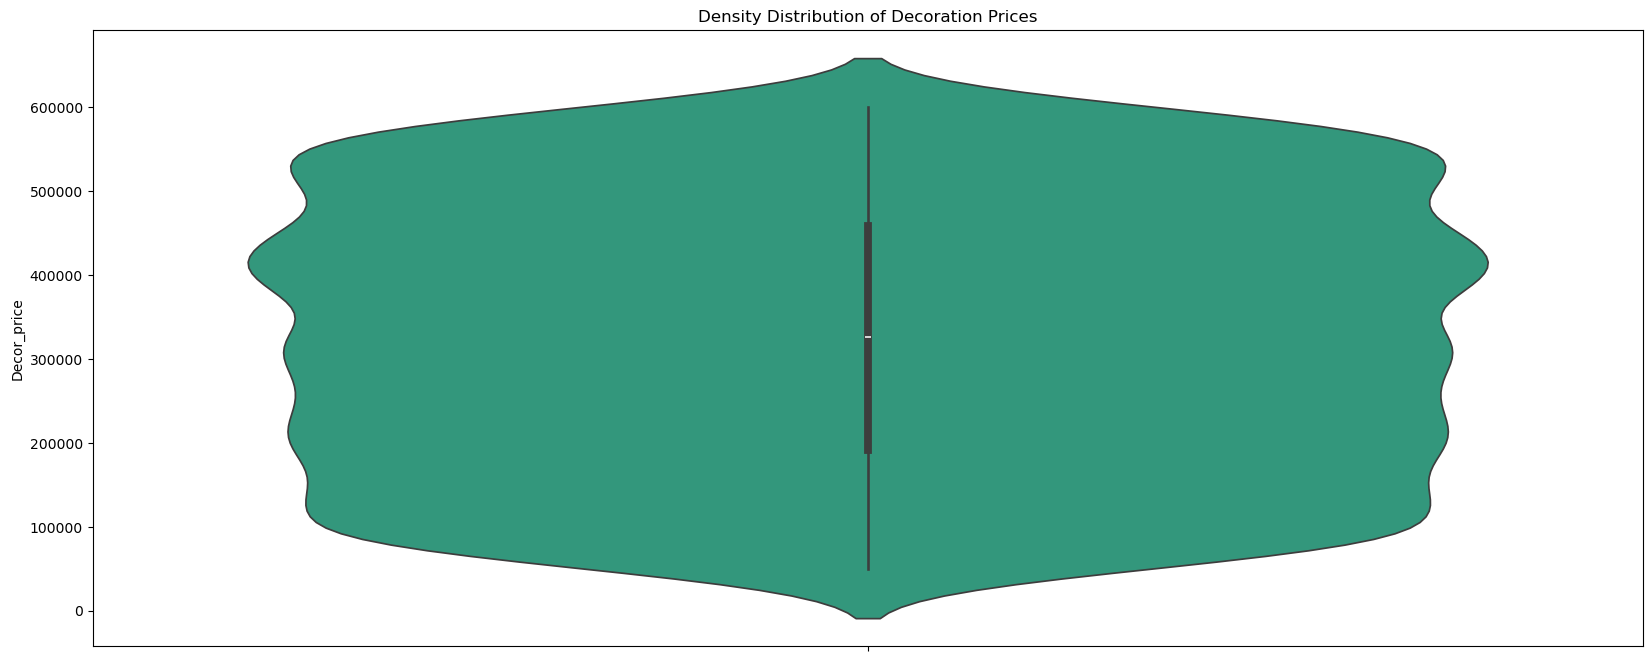

In [82]:
fig=plt.figure(figsize=[20,8])
sb.violinplot(df.Decor_price,color=colors[2])
plt.title('Density Distribution of Decoration Prices')
plt.show()

#### The Analysis shows that the price range between 3.5-4.5 lakhs is common price range for Wedding Decoration.

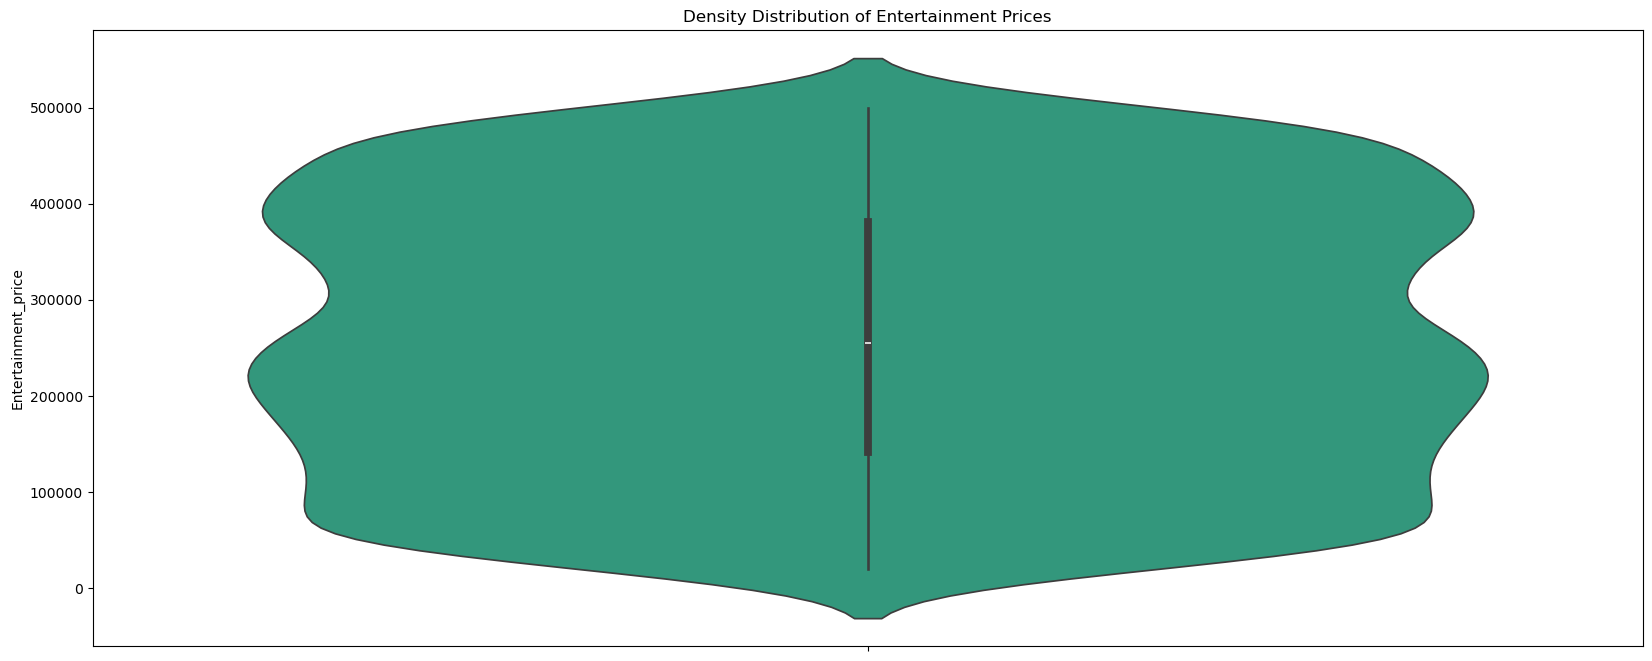

In [83]:
fig=plt.figure(figsize=[20,8])
sb.violinplot(df.Entertainment_price,color=colors[2])
plt.title('Density Distribution of Entertainment Prices')
plt.show()

#### The Analysis shows that the price range between 2.5-3, 3.5-4 lakh is most common price range for entertainment expenditure. 

<Figure size 2000x800 with 0 Axes>

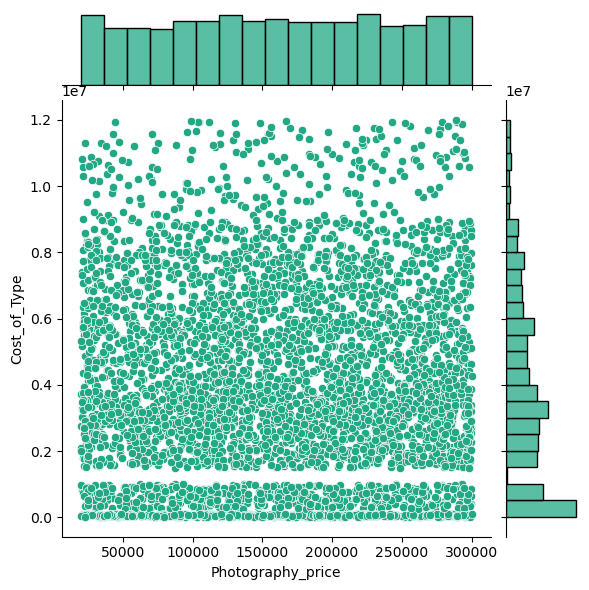

In [77]:
plt.figure(figsize=(20,8))
sb.jointplot(x=df.Photography_price,y=df.Cost_of_Type,color=colors[2])
plt.show()

#### The Total budget varies widely but the photography market is remarkably consistent and independent of that total budget.

<Figure size 2000x800 with 0 Axes>

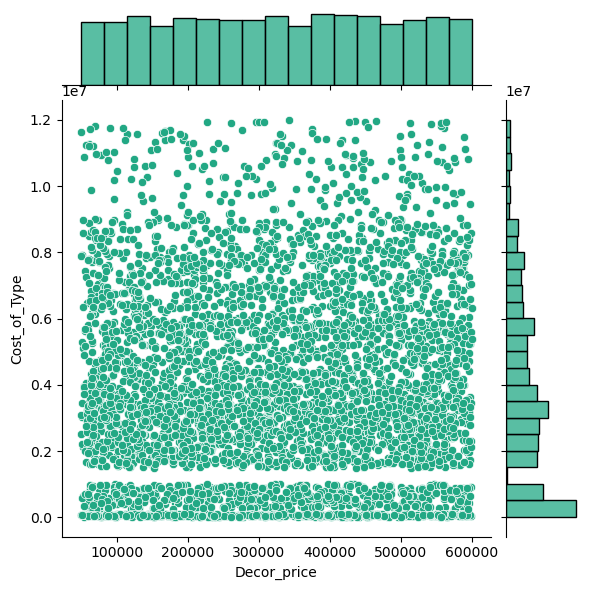

In [78]:
plt.figure(figsize=(20,8))
sb.jointplot(x=df.Decor_price,y=df.Cost_of_Type,color=colors[2])
plt.show()

#### The Analysis shows thatDecor pricing seems independent of the overall Wedding cost.

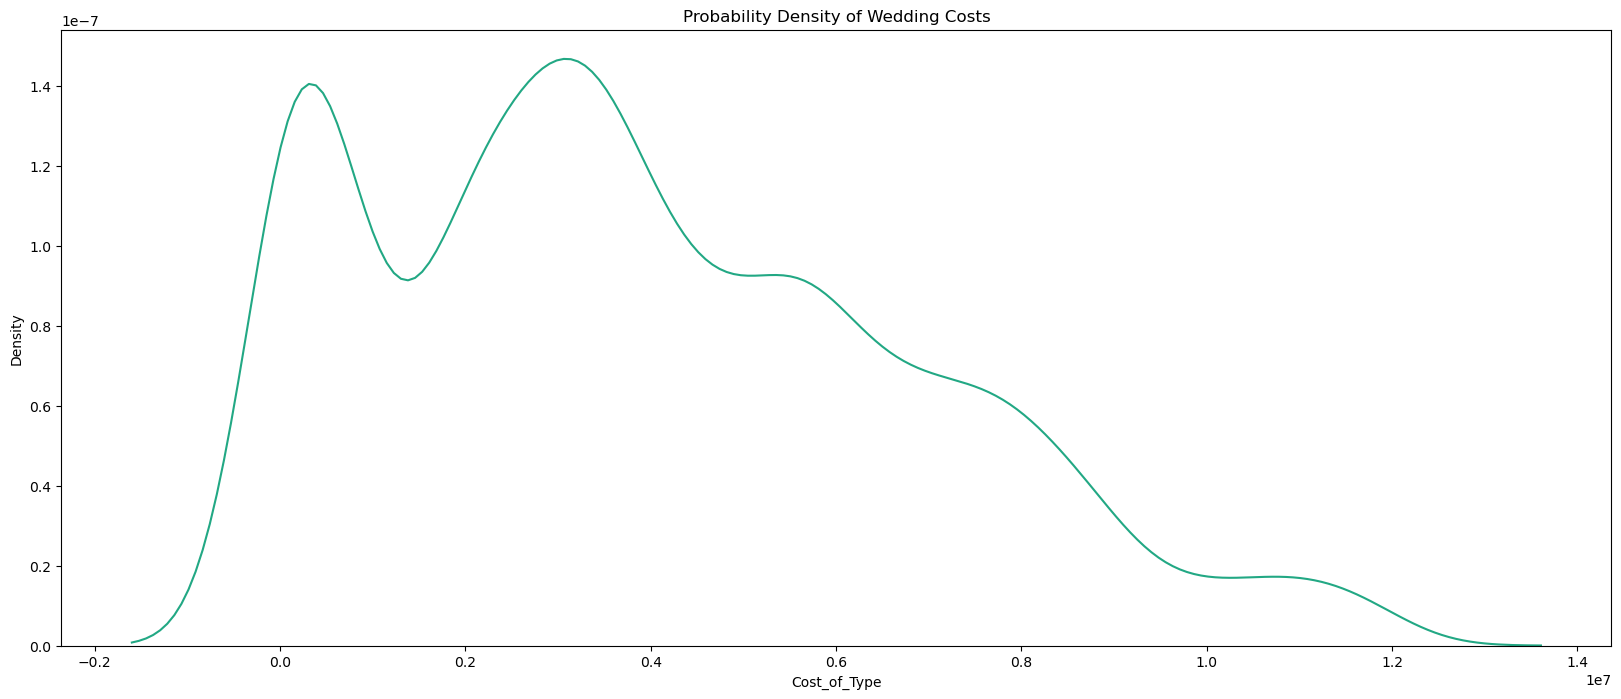

In [79]:
plt.figure(figsize=(20,8))
sb.kdeplot(df.Cost_of_Type,color=colors[2])
plt.title('Probability Density of Wedding Costs')
plt.show()


### The distribution of wedding costs is positively skewed, indicating that most weddings fall in the low to mid-cost range, while a few high-cost weddings create a long tail.

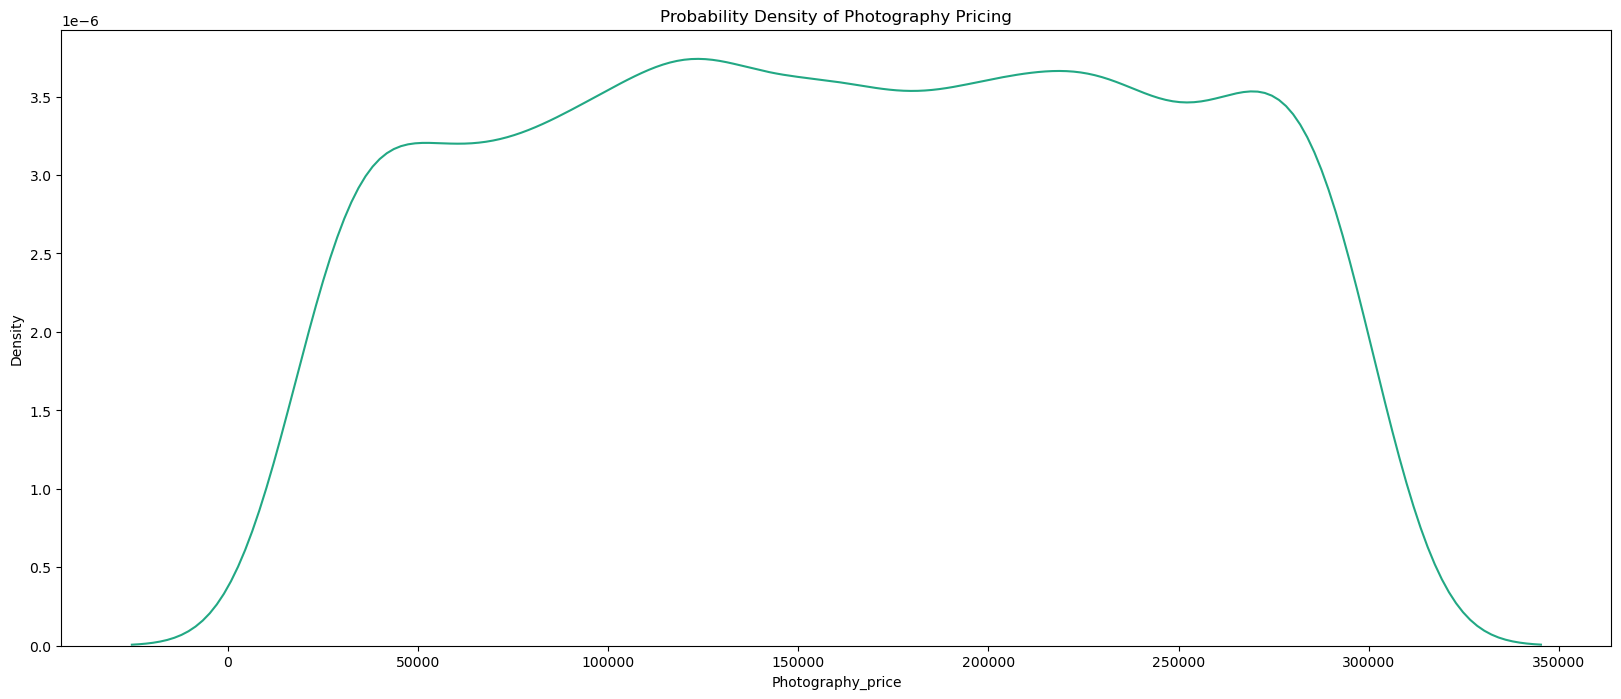

In [80]:
plt.figure(figsize=(20,8))
sb.kdeplot(df.Photography_price,color=colors[2])
plt.title('Probability Density of Photography Pricing')
plt.show()


['Heritage Weddings' 'Palace Weddings' 'Resort Weddings' 'Cruise Weddings'
 'Farmhouse Weddings' 'Beach Weddings' 'Temple Weddings' 'Hotel Weddings'
 'Destination Weddings']


Enter Wedding Type: Temple Weddings


['Agatti Island' 'Mussoorie' 'New Delhi' 'Tirupati' 'Rishikesh' 'Udaipur'
 'Mumbai' 'Jaisalmer' 'Nainital' 'Alibaug' 'Goa' 'Neil Island' 'Jaipur'
 'Varanasi' 'Bangalore' 'Jodhpur' 'Hyderabad' 'Bangaram Island' 'Lonavala'
 'Shimla']


Enter Place: Tirupati


['Luxury Package' 'Venue Decor' 'Floral Decor']


Enter Decor Category: Floral Decor


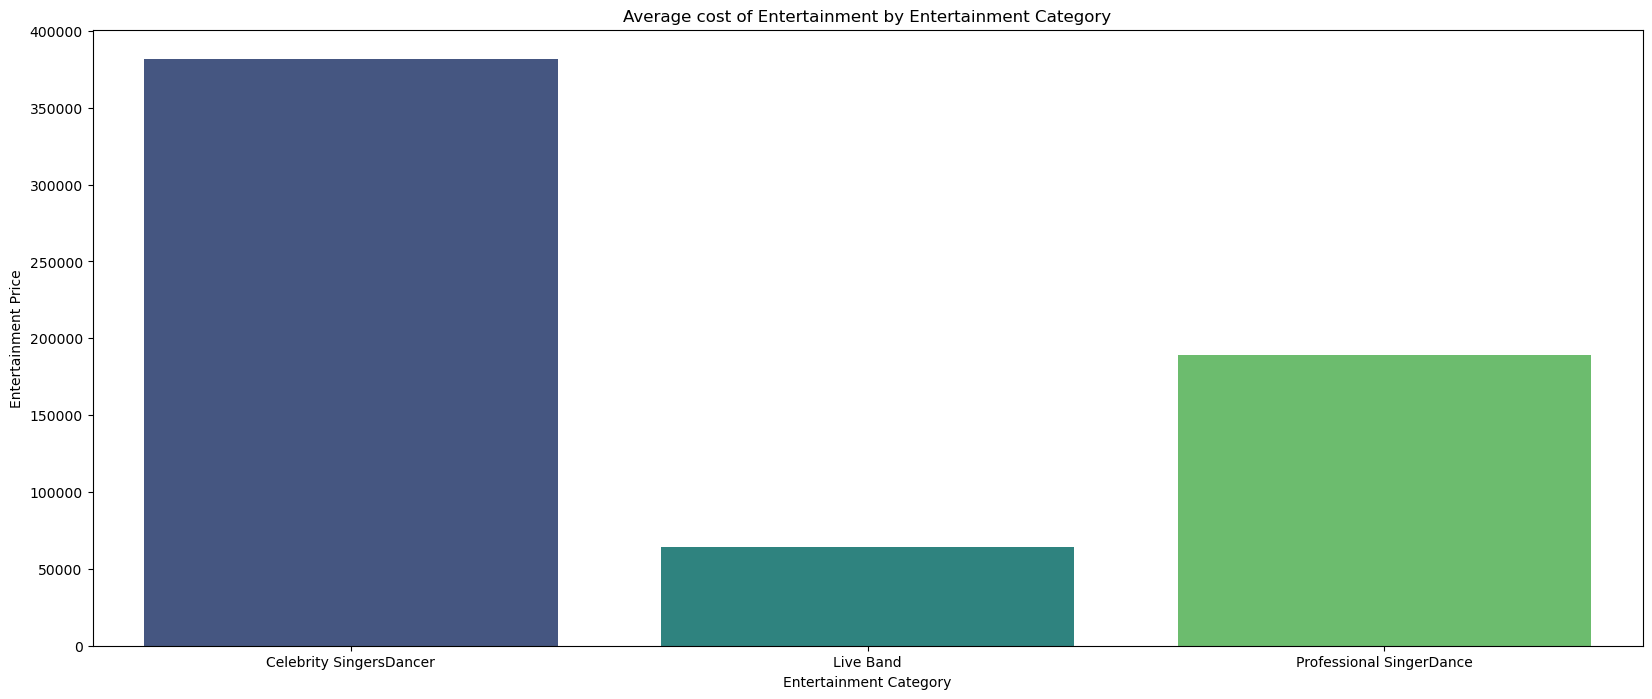

In [107]:
print(df.Weddinng_Type.unique())
a=input("Enter Wedding Type:")
aa=df[df.Weddinng_Type==a]
print(aa.Place.unique())
b=input("Enter Place:")
bb=aa[aa.Place==b]
print(bb.Decor_Category.unique())
c=input("Enter Decor Category:")
cc=bb[bb.Decor_Category==c]
plt.figure(figsize=(20,8))
d=cc.groupby('Entertainment_Category')['Entertainment_price'].mean()
sb.barplot(x=d.index,y=d.values,palette="viridis",hue=d.index,legend=False)
plt.xlabel('Entertainment Category')
plt.ylabel('Entertainment Price')
plt.title('Average cost of Entertainment by Entertainment Category')
plt.show()



#### This interactive filtering creates a personalized "Wedding Cost Calculator",revealing exactly how entertainment prices fluctuate based on specific combinations of location and decor style.